# Evaluación 3

Integrante 1: Paz Valdes

Integrante 2: Maximiliano Matus

Integrante 3: Santiago Franichevic

Correo electronico integrante 1: paz\.valdes2301@alumnos\.ubiobio\.cl

Correo Electrónico integrante 2: maximiliano\.matus2301@alumnos\.ubiobio\.cl

Correo Electrónico integrante 3: santiago\.franichevic2301@alumnos\.ubiobio\.cl

Fecha de Creación: Junio de 2026

Versión: 1\.0

<hr>

### Descripción

Este notebook contiene el desarrollo de la evaluación número 3 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción\.

### Requisitos de Software

Este notebook fue desarrollado con Python 3\.12\. A continuación se listan las bibliotecas necesarias:

- pandas \(\>=1\.1\.0\)

- matplotlib \(3\.7\.1\)

- numpy \(2\.0\.2\)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

In [1]:
import pandas as pd
print(pd.__version__)

2.1.4


## Carga de datos

In [2]:
!wget https://raw.githubusercontent.com/DaFrokki/620454/refs/heads/main/data/ingestion/data_fraude.csv

--2026-06-12 02:55:52--  https://raw.githubusercontent.com/DaFrokki/620454/refs/heads/main/data/ingestion/data_fraude.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2283664 (2.2M) [text/plain]
Saving to: ‘data_fraude.csv.6’

data_fraude.csv.6   100%[===================>]   2.18M  --.-KB/s    in 0.1s    

2026-06-12 02:55:54 (21.5 MB/s) - ‘data_fraude.csv.6’ saved [2283664/2283664]



In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [4]:
data = pd.read_csv("data_fraude.csv")
data.head()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


## Objetivo

 Identificar transacciones fraudulentas de forma eficiente\.

# Entendimiento de los datos

In [5]:
target = "is_fraud"

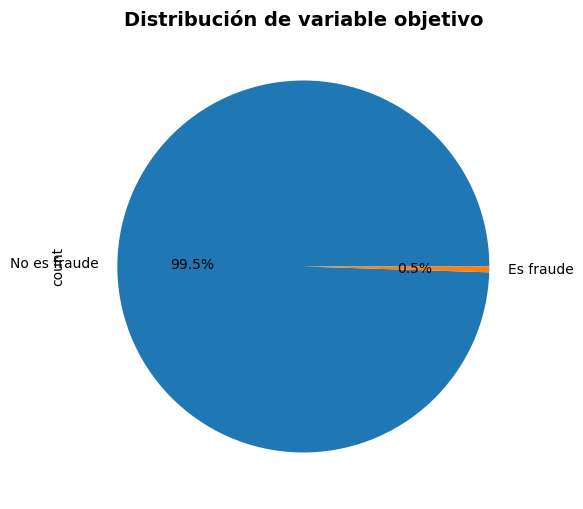

In [6]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No es fraude', 'Es fraude'],
                                 figsize=(6,7))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

# Revisión de nulos

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  object 
 10  device_type                20000 non-null  object 
 11  location_region            20000 non-null  object 
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non-null  int

# Revisión de atípicos

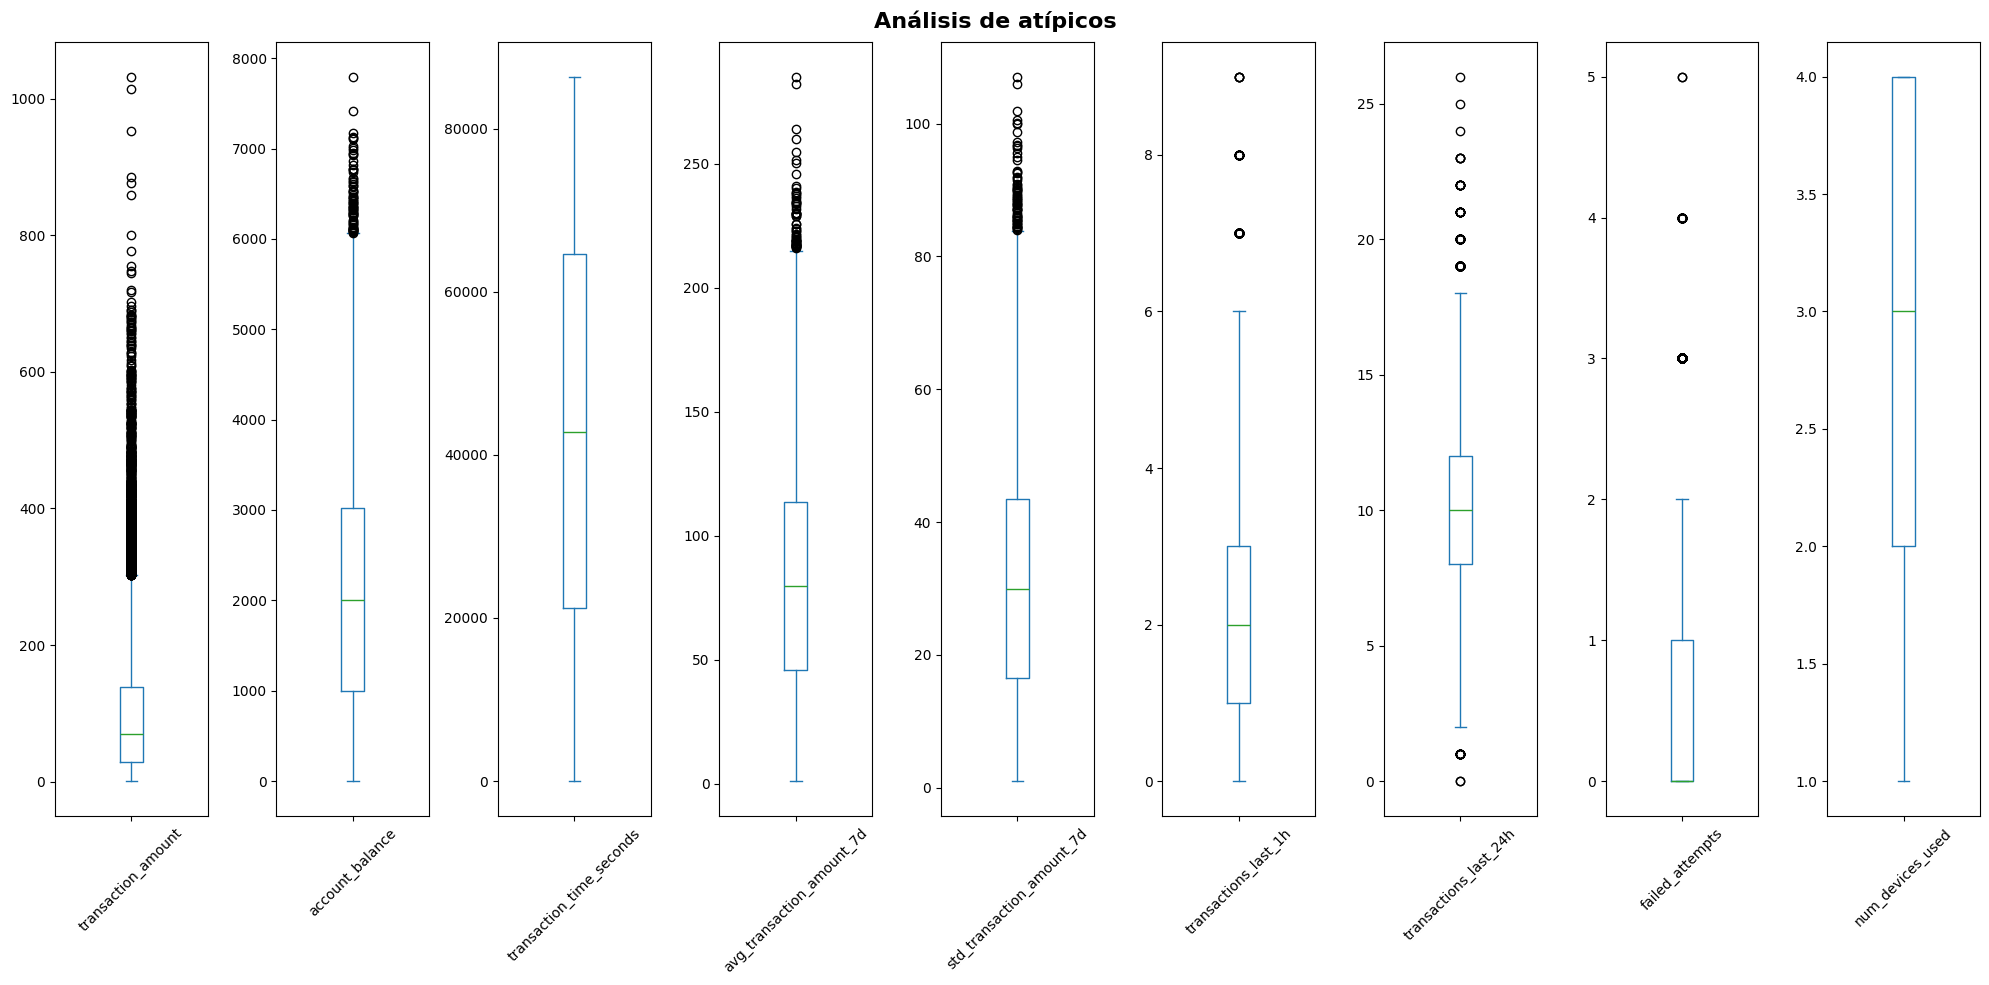

In [8]:
# Revisión de atipicos en variables cuantitativas
revision_atipicos = ['transaction_amount', 'account_balance', 'transaction_time_seconds',
    'avg_transaction_amount_7d', 'std_transaction_amount_7d',
    'transactions_last_1h', 'transactions_last_24h', 'failed_attempts','num_devices_used'
]
# Codigo para realizar los boxplots con dichas variables
fig, axes = plt.subplots(1, 9, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(20,10), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

# Revisión de inconsistencias

In [9]:
# Revisión de inconsistencias Cuantitativas

inconsistentes = data[(data["transaction_amount"] <= 0) | 
(data["account_balance"] < 0) | (data["transaction_time_seconds"] < 0) | 
(data["avg_transaction_amount_7d"] < 0) | (data["transactions_last_1h"] < 0) | 
(data["transactions_last_24h"] < 0) | (data["failed_attempts"] < 0) |
(data["num_devices_used"] < 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


In [10]:
# Inconsistencias cualitativas
data['transaction_type'].unique()

array(['transfer', 'withdrawal', 'purchase', 'payment'], dtype=object)

In [11]:
data['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [12]:
data['location_region'].unique()

array(['rural', 'suburban', 'urban'], dtype=object)

In [13]:
# Muestra los datos cuantitativos
data.drop(columns=['transaction_type','device_type','location_region']).describe()

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,is_foreign_transaction,is_high_risk_country,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,100.596829,2073.293303,42986.240550,80.827345,30.656022,2.014950,9.958900,0.506400,2.508900,0.103900,0.049950,0.005000
std,100.820016,1382.966545,24953.783088,47.662985,18.730756,1.412596,3.149747,0.715251,1.117624,0.305138,0.217847,0.070535
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.047406,993.130299,21259.000000,45.632425,16.527547,1.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,70.059997,2008.125418,42778.500000,79.503855,29.987126,2.000000,10.000000,0.000000,3.000000,0.000000,0.000000,0.000000
75%,138.419340,3022.548675,64656.750000,113.517787,43.476224,3.000000,12.000000,1.000000,4.000000,0.000000,0.000000,0.000000
max,1032.072330,7794.605317,86397.000000,285.026236,107.052797,9.000000,26.000000,5.000000,4.000000,1.000000,1.000000,1.000000


In [14]:
# Muestra los datos cualitativos
data.describe(include="object")

,transaction_type,device_type,location_region
count,20000,20000,20000
unique,4,3,3
top,transfer,mobile,rural
freq,5068,11991,6726


In [15]:
# Limitar todo lo que debe ser positivo
cols_min0 = ['account_balance', 'transaction_time_seconds','transactions_last_1h','transactions_last_24h',  'failed_attempts']
data[cols_min0] = data[cols_min0].clip(lower=0)

cols_min1 = ['transaction_amount', 
    'avg_transaction_amount_7d', 'std_transaction_amount_7d',
    'num_devices_used']
data[cols_min1] = data[cols_min1].clip(lower = 1)

## Cantidad de duplicados

In [16]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)]

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


# Preparación de datos

## Corrección de inconsistencias: Valores negativos

Basándonos en la detección de inconsistencias, se identificarán las columnas que pueden contener valores negativos y se aplicará la función de valor absoluto para corregirlos\.

In [17]:
# Columnas identificadas con posibles valores negativos o cero que deberían ser positivos
columns_to_correct = [
   'transaction_amount', 
    'avg_transaction_amount_7d', 'std_transaction_amount_7d',
    'num_devices_used'
]

for col in columns_to_correct:
    data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


## Re\-verificación de inconsistencias

In [18]:
# Detectar inconsistencias nuevamente después de la corrección
inconsistentes_corregido = data[(data["account_balance"] < 0) | (data["transaction_time_seconds"] < 0) | 
(data["avg_transaction_amount_7d"] < 0) | (data["transactions_last_1h"] < 0) | 
(data["transactions_last_24h"] < 0) | (data["failed_attempts"] < 0) |
(data["num_devices_used"] < 0)]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

if inconsistentes_corregido.empty:
    print("¡No se encontraron inconsistencias de valores negativos después de la corrección!")
else:
    print("Aún existen inconsistencias, revisar la lógica.")

Registros inconsistentes encontrados después de la corrección:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


¡No se encontraron inconsistencias de valores negativos después de la corrección!


In [19]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [20]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None
    self.feature_names_in_ = None

  def fit(self, X, y=None):
    # Ensure X is a DataFrame, assuming upstream transformers use set_output(transform='pandas')
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    self.feature_names_in_ = X_df.columns

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    # Ensure X is a DataFrame
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered # Return DataFrame, not .values

  def get_feature_names_out(self, input_features=None):
    current_features = input_features if input_features is not None else self.feature_names_in_

    if current_features is None:
        raise ValueError("CorrelationFilter no tiene acceso a las variables con las que fue entrenado el modelo")

    current_feature_index = pd.Index(current_features)
    output_features = current_feature_index.drop(self.columns_to_drop_, errors='ignore')
    return np.array(output_features)

In [29]:
num_cols = ['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country']
cat_cols = ["transaction_type", "device_type", "location_region"]
# Preprocesamiento numérico: imputación con media
numeric_preprocess = Pipeline(steps=[
    ('winsorizer',Winsorizer()),
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
# Preprocesamiento categórico: imputación + one-hot encoding
categorical_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop="first",handle_unknown='ignore'))
])
#One hot encoding, transforma todo a codigo para que lo pueda leer mas facilmente la maquina
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess, num_cols),
        ('cat', categorical_preprocess, cat_cols)
    ],
    remainder="passthrough",
)

pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("preprocesamiento", preprocess)
    ]
)

preprocess
df_clean = pipeline_limpieza_transformacion.fit_transform(data)
data_clean = pd.DataFrame(
    df_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)
data_clean.to_csv('data_fraude_clean.csv', index=False)
print('datos limpios guardados como data_fraude_clean.csv')

datos limpios guardados como data_fraude_clean.csv


# Evaluación de mejores variables predictoras

In [21]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

is_fraud                     1.000000
is_high_risk_country         0.201771
failed_attempts              0.121273
transactions_last_1h         0.099618
is_foreign_transaction       0.098992
transaction_amount           0.050008
transactions_last_24h        0.001600
transaction_time_seconds     0.001429
avg_transaction_amount_7d    0.000671
account_balance             -0.000361
num_devices_used            -0.008810
std_transaction_amount_7d   -0.012300
Name: is_fraud, dtype: float64

In [22]:
for columna in ["transaction_type", "location_region", "device_type"]:
  print(f"Análisis {columna}")
  display(data.groupby(columna)[target].value_counts().sort_values().round(2))

Análisis transaction_type


transaction_type  is_fraud
withdrawal        1             16
purchase          1             17
payment           1             21
transfer          1             46
payment           0           4874
purchase          0           5002
withdrawal        0           5002
transfer          0           5022
Name: count, dtype: int64

Análisis location_region


location_region  is_fraud
urban            1             28
rural            1             34
suburban         1             38
urban            0           6593
suburban         0           6615
rural            0           6692
Name: count, dtype: int64

Análisis device_type


device_type  is_fraud
tablet       1               2
desktop      1              10
mobile       1              88
tablet       0            2024
desktop      0            5973
mobile       0           11903
Name: count, dtype: int64

# Modelamiento

In [23]:
data.describe().columns

Index(['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country',
       'is_fraud'],
      dtype='object')

In [24]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

In [25]:
# Variables
features_num = ['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country']
features_cat = ["transaction_type", "device_type", "location_region"]

X = data[features_num + features_cat]
y = data[target]

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)
preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('winsorizer', Winsorizer()),
                                                 ('imputer', SimpleImputer()),
                                                 ('escalado',
                                                  StandardScaler())]),
                                 ['transaction_amount', 'account_balance',
                                  'transaction_time_seconds',
                                  'avg_transaction_amount_7d',
                                  'std_transaction_amount_7d',
                                  'transactions_last_1h',
                                  'transactions_last_24h', 'failed_attempts',
                                  'num_devices_used', 'is_foreign_transaction',
                                  'is_high_risk_country']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['transaction_type', 'device_type',
                                  'location_region'])])

In [27]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [28]:
# División train/test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

# LogisticRegression

## Modelo base

In [29]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_lr = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LogisticRegression(class_weight="balanced"))
])

In [30]:
# Evaluación
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr['recall']:.4f}")

Accuracy            : 0.9307
F1 Score:           : 0.1150
ROC AUC Score       : 0.9777
Precision           : 0.0614
Recall              : 0.9000


In [31]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.91756
Score del modelo en test                :0.93075


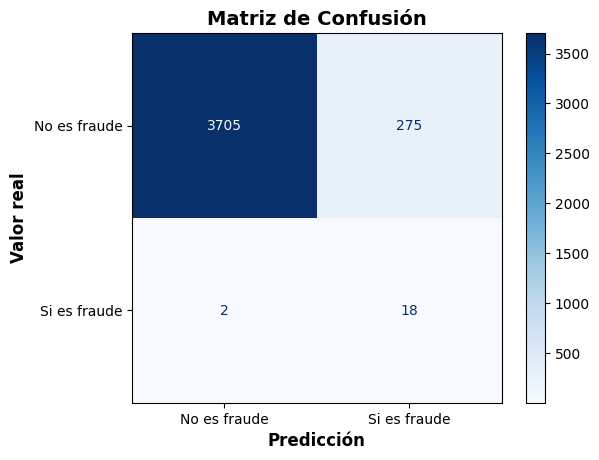

In [32]:
y_pred = pipeline_modelo_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No es fraude", "Si es fraude"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

## Aplicando GridSearchCV

In [33]:
param_grid_lr = {
      'modelo__penalty': ['l2'],
      'modelo__C': [0.01, 0.1, 1, 10, 100],
      'modelo__max_iter': [500, 1000]}

In [34]:
grid_lr = GridSearchCV(
    pipeline_modelo_lr,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transaction_time_seconds',...
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo',
                                        LogisticRegression(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10, 100],
                         'modelo__max_iter': [500, 1000],
                         'modelo__penalty': ['l2']},
             scoring='f1')

In [35]:
grid_lr.best_params_

{'modelo__C': 1, 'modelo__max_iter': 500, 'modelo__penalty': 'l2'}

In [36]:
best_model_lr = grid_lr.best_estimator_
# Evaluación
metricas_lr_mejor = evaluar(best_model_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr_mejor['recall']:.4f}")

Accuracy            : 0.9307
F1 Score:           : 0.1150
ROC AUC Score       : 0.9777
Precision           : 0.0614
Recall              : 0.9000


In [37]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.91756
Score del modelo en test                :0.93075


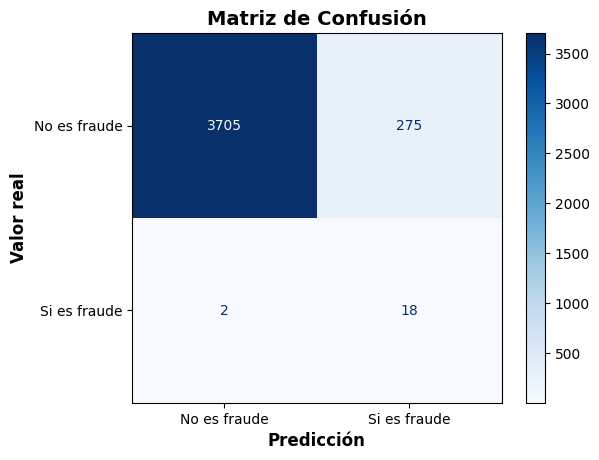

In [38]:
y_pred = best_model_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No es fraude", "Si es fraude"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

# DecisionTree Classifier

## Modelo linea base

In [39]:
# Preprocesamiento numérico: imputación con media
numeric_transformer_dt = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)

In [40]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_dt),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier(class_weight="balanced"))
])

In [41]:
# Evaluación
metricas_dtc = evaluar(pipeline_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.9908
F1 Score:           : 0.1395
ROC AUC Score       : 0.5725
Precision           : 0.1304
Recall              : 0.1500


In [42]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.99075


In [43]:
X.columns

Index(['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country',
       'transaction_type', 'device_type', 'location_region'],
      dtype='object')

## Aplicando GridSearchCV

In [44]:
param_grid_dt = {
    "modelo__max_depth": range(3,6),
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    #"modelo__class_weight": [None, "balanced"]
}

grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer()),
                                                                                         ('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transaction_time_seconds',
                                                                          'avg_transaction_amount_7d',
                                                                          's...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo',
                                        DecisionTreeClassifier(class_weight='balanced'))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': range(3, 6),
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [45]:
mejor_modelo_dtc = grid_dt.best_estimator_

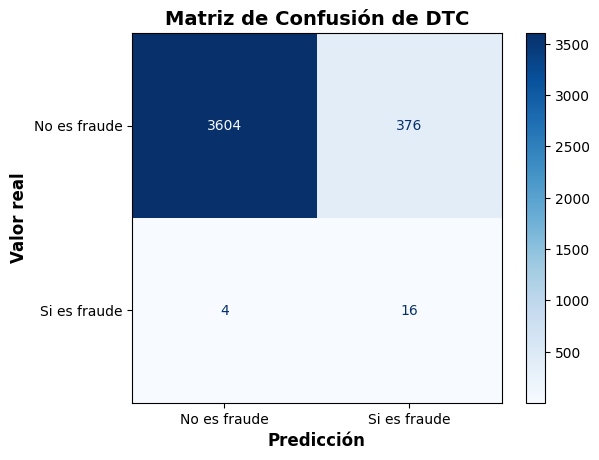

In [46]:
y_pred = mejor_modelo_dtc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No es fraude", "Si es fraude"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión de DTC", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [47]:
# Evaluación
metricas_dtc = evaluar(mejor_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.9050
F1 Score:           : 0.0777
ROC AUC Score       : 0.8759
Precision           : 0.0408
Recall              : 0.8000


In [48]:
# Obtiene las probabilidades
y_pred_proba = best_model_lr.predict_proba(X_test)[:, 1]

## Ajuste de threshold a mejor modelo

In [49]:
def verMatrizUmbral(a_probabilidades: np.array, umbral: float):
    """
    Obtiene la matriz de confusión usando un determinado umbral

    Parámetros
    ----------
    a_probabilidades : np.array
        Probabilidades de la clase positiva.
    umbral : float
        Umbral para la clasificación.
    """
    y_pred_umbral = (a_probabilidades >= umbral).astype(int)
    cm = confusion_matrix(y_test, y_pred_umbral)

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred_umbral)
    f1 = f1_score(y_test, y_pred_umbral)
    roc_auc = roc_auc_score(y_test, a_probabilidades)
    precision = precision_score(y_test, y_pred_umbral)
    recall = recall_score(y_test, y_pred_umbral)
    
    # Mostrar métricas
    print(f"--- RESULTADOS CON UMBRAL {umbral} ---")
    print(f"{'Accuracy':<20}: {accuracy:.4f}")
    print(f"{'F1 Score:':<20}: {f1:.4f}")
    print(f"{'ROC AUC Score':<20}: {roc_auc:.4f}")
    print(f"{'Precision':<20}: {precision:.4f}")
    print(f"{'Recall':<20}: {recall:.4f}")
    
    # Guardar CSV con predicciones
    
    df = pd.DataFrame({
         'probabilidad': a_probabilidades,
         'valor_real': y_test,
         f'prediccion_umbral_{umbral}': y_pred_umbral
    })
    nombre_archivo = f'predicciones_umbral_{umbral}.csv'
    df.to_csv(nombre_archivo, index=False)
    print(f"\n✓ Archivo guardado: {nombre_archivo}")

    #Mostrar Matriz de Confución

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No es Fraude", "Si es Fraude"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
    plt.xlabel("Predicción", fontweight="bold", fontsize=12)
    plt.ylabel("Valor real", fontweight="bold", fontsize=12)
    plt.show()

--- RESULTADOS CON UMBRAL 0.3 ---
Accuracy            : 0.8978
F1 Score:           : 0.0891
ROC AUC Score       : 0.9777
Precision           : 0.0466
Recall              : 1.0000

✓ Archivo guardado: predicciones_umbral_0.3.csv


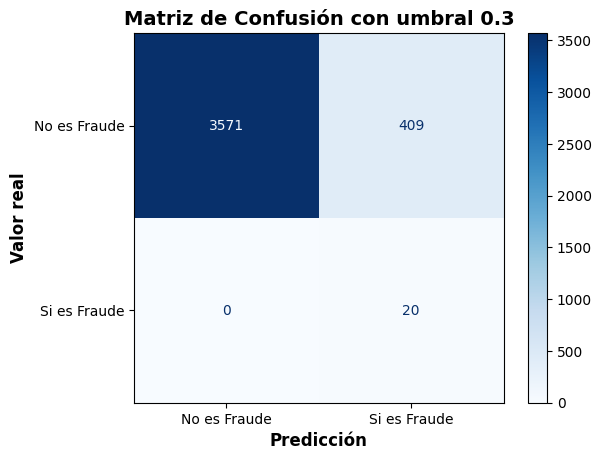

In [50]:
verMatrizUmbral(y_pred_proba,0.3)

--- RESULTADOS CON UMBRAL 0.5 ---
Accuracy            : 0.9307
F1 Score:           : 0.1150
ROC AUC Score       : 0.9777
Precision           : 0.0614
Recall              : 0.9000

✓ Archivo guardado: predicciones_umbral_0.5.csv


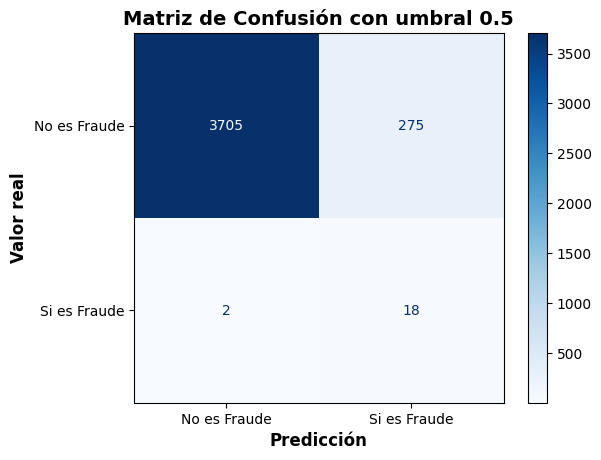

In [51]:
verMatrizUmbral(y_pred_proba,0.5)

--- RESULTADOS CON UMBRAL 0.7 ---
Accuracy            : 0.9533
F1 Score:           : 0.1538
ROC AUC Score       : 0.9777
Precision           : 0.0846
Recall              : 0.8500

✓ Archivo guardado: predicciones_umbral_0.7.csv


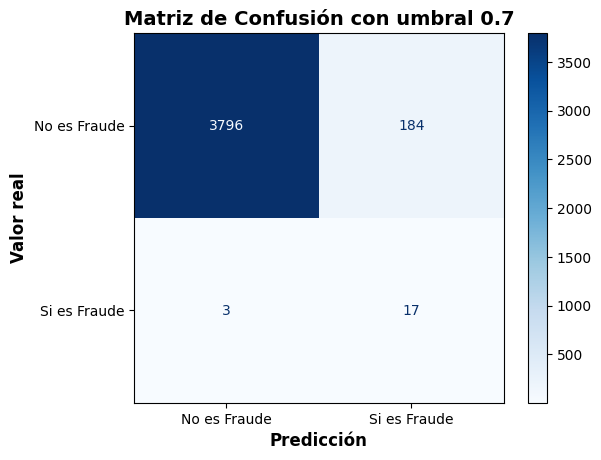

In [52]:
verMatrizUmbral(y_pred_proba,0.7)

In [53]:
print(f"{'Score del modelo en entrenamiento':<40}:{mejor_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{mejor_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.89506
Score del modelo en test                :0.90500


In [54]:
grid_dt.best_params_

{'modelo__max_depth': 5,
 'modelo__min_samples_leaf': 1,
 'modelo__min_samples_split': 2}

In [55]:
mejor_modelo = mejor_modelo_dtc.named_steps["modelo"]

Profundidad del árbol: 5
Número de nodos terminales: 25


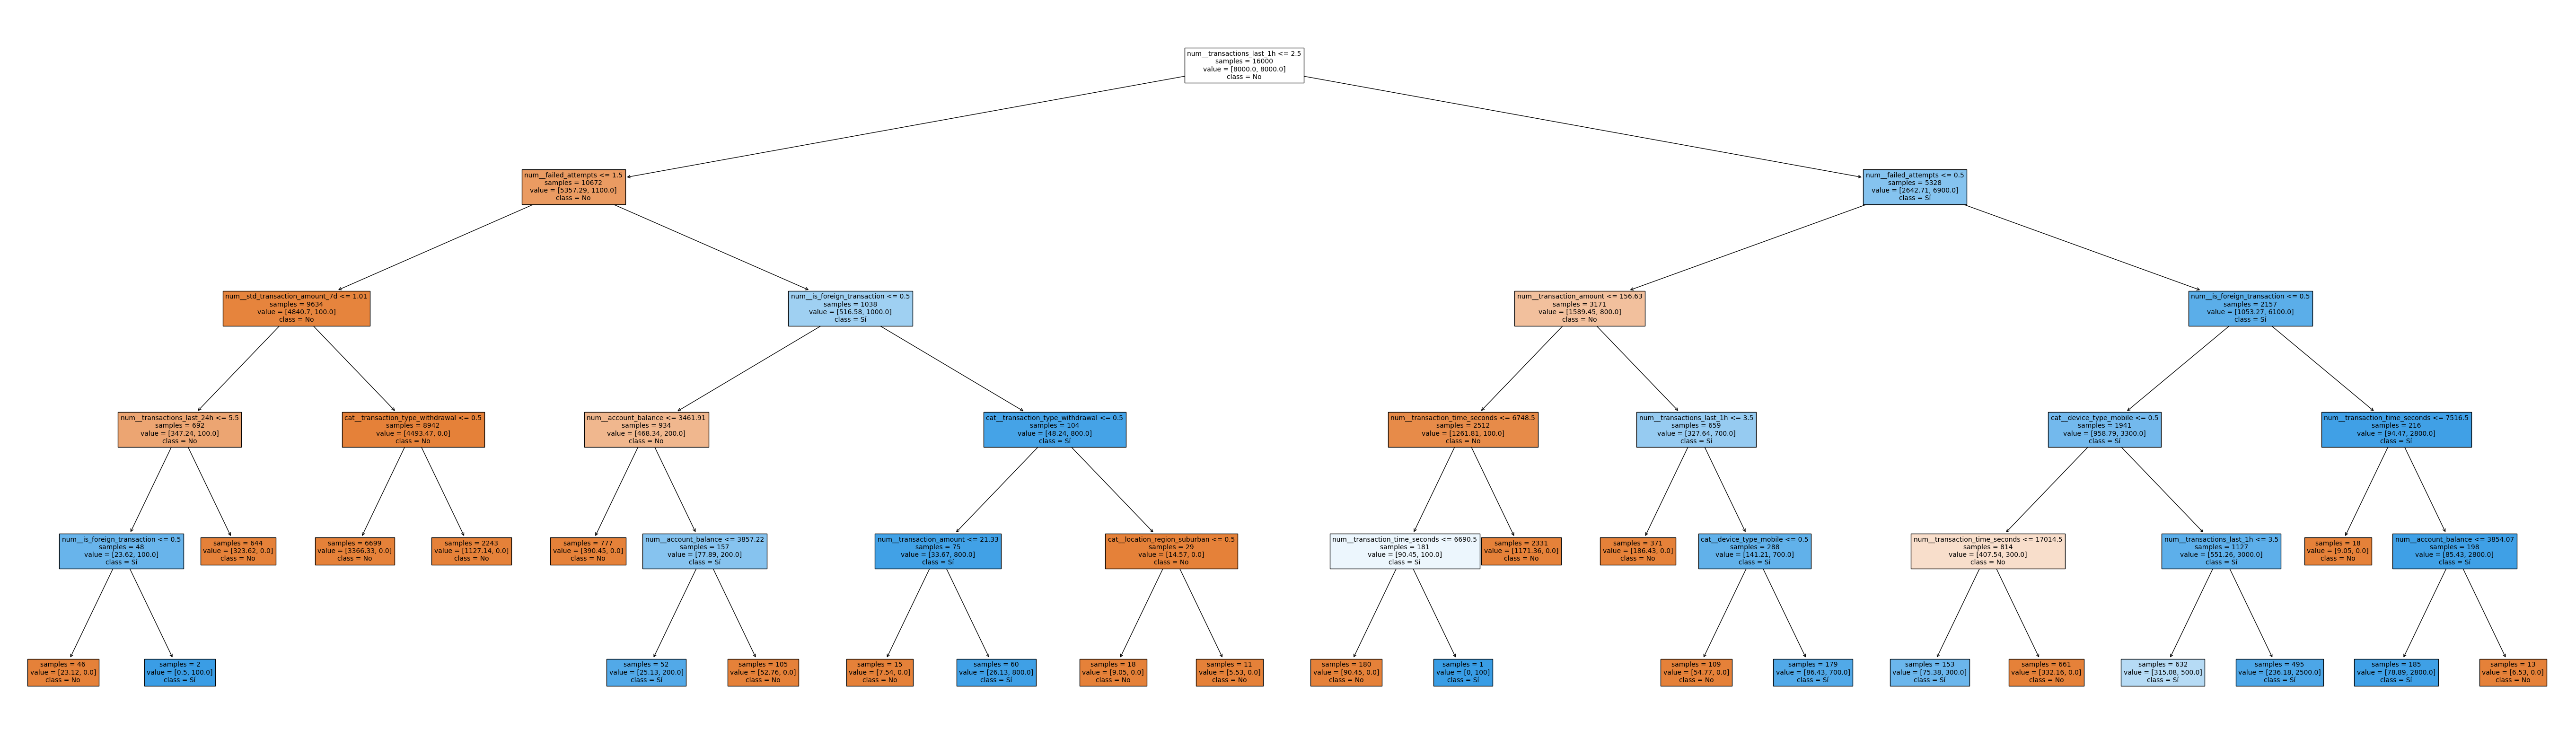

In [56]:
fig, ax = plt.subplots(figsize=(70, 20))

print(f"Profundidad del árbol: {mejor_modelo.get_depth()}")
print(f"Número de nodos terminales: {mejor_modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = mejor_modelo,
            feature_names = mejor_modelo_dtc[:-1].get_feature_names_out(),
            class_names = ["No", "Sí"],
            filled         = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

## Respuestas preguntas

PARTE 1\.4\)

- Las variables transaction\_type, device\_type y location\_region fueron clasificadas como texto ya que son de tipo object \(texto\) y no se puede operar con ellas como texto\. El resto de variables fueron clasificadas como numéricas sin tener que agregar una transformación adicional

- Para el Encoding de variables categóricas se utilizó OneHotEncoding, para no imponer jerarquía y cada variable se mantenga independiente\. Acompañado de con drop = "first" que se realizó para evitar la multicolinealidad perfecta\.

- Para Regresión Logística se aplica StandarScaler\(\), mientras que para Decision Tree no, ya que ambos tienen distinta sensibilidad antes las escalas grandes de datos, en este caso, el arbol trabaja con cortes sobre umbrales de cada variable de forma independiente, por lo que la escala no afecta sus decisiones y escalar sería innecesario\.

-  El 80/20 es la proporción estándar que balancea tener suficientes datos para entrenar y suficientes para evaluar con confianza\. El parámetro stratify=y es el más importante en este contexto: dado el fuerte desbalance de clases del dataset, sin estratificación podría ocurrir que el conjunto de prueba quede con muy pocos ejemplos de fraude, haciendo la evaluación poco representativa; con stratify se garantiza que la proporción fraude/no\-fraude se mantiene igual en ambos conjuntos\. Finalmente, random\_state=29 fija la semilla aleatoria para que la partición sea reproducible en cualquier ejecución\.

PARTE 2\.3\. a\) y b\) Mejores hiperparámetros y métrica de optimización

La métrica utilizada para optimizar ambos modelos fue el F1\-score, configurada con scoring="f1" en el GridSearchCV\. Esta elección es apropiada dado el desbalance de clases, ya que el F1 combina precisión y recall en una sola métrica y penaliza cuando el modelo falla en detectar fraudes reales\. Para la Regresión Logística, los mejores hiperparámetros encontrados fueron C=10, penalty='l2' y max\_iter=500: el valor alto de C indica poca regularización, lo que significa que el modelo confía más en los datos de entrenamiento que en penalizar la complejidad\. Para el Decision Tree, los mejores fueron max\_depth=5, min\_samples\_split=10, min\_samples\_leaf=2 y class\_weight=None: una profundidad de 5 limita el árbol para evitar overfitting, mientras que los parámetros de samples exigen cierta cantidad mínima de observaciones antes de dividir o formar una hoja, controlando así la generalización\.

 PARTE 2\.4\) Comparación de rendimiento entre modelos

Al comparar ambos modelos optimizados sobre el conjunto de prueba, el Logistic Regression obtiene Accuracy: 0\.9307, 
F1 Score: 0\.1150, ROC AUC Score: 0\.9777, Precision: 0\.0614, Recall: 0\.9000, mientras que el Decision Tree obtiene Accuracy: 0\.9050, F1 Score: 0\.0777, ROC AUC Score: 0\.8759, Precision: 0\.0408, Recall: 0\.8000\. Esto indica que ambos modelos son bastante similares en lo que respecta a rendimiento, sin embargo podemos observar que el Logistic Regression tiene un rendimiento un poco mejor en comparación, observando que tiene valores superiores en todos los parámetros medidos\.

PARTE 2\.5\) Modelo seleccionado y justificación

Se debe seleccionar el Logistic Regression como el mejor modelo ya que es superior en todos los parametros medidos, pero al mismo tiempo se pudo observar que el DecisionTree posee una mayor cantidad de falsos positivos y una menos cantidad de aciertos positivos, lo que nos indica que este modelo es menos probable que acierte en detectar un fraude y más probable de que culpe a alguien de estar cometiendo fraude cuando no es así lo que se explica en su Recall de 0\.8000 en comparación con el Recall de 0\.9000 que posee el LogisticRegression

PARTE 3\.4\) Interpretación de resultados con threshold = 0,5 en contexto de fraude

El modelo con threshold por defecto de 0\.5 presenta un comportamiento más matizado de lo que aparenta a primera vista\. El accuracy de 93\.07% sigue siendo una métrica engañosa en este contexto: dado el fuerte desbalance de clases del dataset, este valor no refleja con fidelidad el rendimiento real del modelo sobre la clase minoritaria\. Lo más destacable es el recall de 0\.90, que indica que el modelo logra detectar el 90% de las transacciones fraudulentas reales, lo cual es un resultado muy positivo desde el punto de vista del riesgo de negocio, ya que de cada 100 fraudes que ocurren, el sistema solo deja pasar 10 sin alertar\. Sin embargo, la precision de apenas 0\.0614 revela el principal problema de este umbral: cuando el modelo lanza una alerta de fraude, solo acierta aproximadamente 1 de cada 16 veces, generando una gran cantidad de falsos positivos que friccionan transacciones legítimas y afectan negativamente la experiencia del cliente\. El F1\-score de 0\.115 refleja precisamente este desequilibrio entre ambas métricas, siendo bajo a pesar del buen recall, debido al peso que ejerce la baja precision\. El ROC AUC de 0\.9777 confirma que el modelo posee una capacidad discriminativa muy alta a nivel probabilístico, es decir, internamente distingue bien entre clases, lo que deja abierta la posibilidad de ajustar el threshold para encontrar un punto de corte que mejore la precision sin sacrificar demasiado el recall, equilibrando así la detección de fraude con la experiencia del cliente\.

PARTE 4\.2\) Comparación de resultados entre tresholds

1\. Compare los resultados entre thresholds 

Precision aumenta de forma progresiva pasando de de un 0\.0466 a 0\.0614 hasta 0\.0846, en los thresholds 0\.3, 0\.5 y 0\.7 respectivamente, logrando un aumento total de 0\.038 puntos, lo que indica una leve mejora en la prediccion correcta de los casos de fraude a medida que aumenta el thresholds \.

Recall disminuye de forma progresiva desde 1 a 0\.9 hasta 0\.85, en los thresholds 0\.3, 0\.5 y 0\.7 respectivamente, disminuyendo un total 0\.15 puntos, esto indica que la frecuencia con la cual se detectan casos de fraude disminuye levemente a medida que aumenta el threshold\.

F1 Score aumenta de forma progresiva pasando de de un 0\.0891 a 0\.1150 hasta 0\.1538, en los thresholds 0\.3, 0\.5 y 0\.7 respectivamente, aumentando en total 0\.0647 puntos, esto indica una leve "mejora" en el desempeño general de Recall y Precision\.

ROC AUC Score se mantiene intacto en todos los thresholds , indicando que la diferencia de desempeño entre los 3 modelos es mínima\.

Accuracy cambia levemente pasando de un 0\.9048 en los threshold 0\.3 y 0\.5 a 0\.9357 en el threshold 0\.7, aún así esta medida no es confiable debido al desbalance de clases que se presenta en los datos\.

2\. Analice: 
a\. ¿Qué ocurre con los falsos positivos? 

Los falsos positivos tienden a disminuir a medida que aumenta el threshold, esto sugiere que el modelo tiende menos a detectar transacciones legítimas como fraude a medida que aumenta el treshold\.

b\. ¿Qué ocurre con los falsos negativos? 

Los falsos negativos tienden a aumentar a medida que se aumenta el threshold, esto sugiere que el modelo tiende a detectar con mayor frecuencia transacciones como legítimas que en realidad son transacciones fraudulentas\.

c\. ¿Cómo cambian precision y recall? 

Precision aumenta y Recall disminuye a medida que se aumenta el threshold\. Esto tiene un efecto positivo a fin de cuentas en F1 Score, debido a la diferencia de magnitudes anteriormente mencionada en la comparación de resultados, sin embargo F1 Score posee valores muy bajos en un contexto donde ambos errores son importantes \(tanto detectar un fraude tarde, como detectar incorrectamente una transaccion legítima\), este bajo desempeño es producido porque el modelo falla en Precision, lo cual da a entender que se debe mejorar el modelo\.

PARTE 4\.3\) Decisión de negocio

¿Qué threshold, de todos los analizados, elegiría para este problema? 
• Justifique su respuesta considerando: 
o Riesgo de fraude 
o Impacto en clientes 
o Métricas obtenidas

El umbral que eligiría sería el 0\.5, ya que representa el balance más adecuado entre los tres factores analizados\. En términos de riesgo de fraude,  aunque no acierte todos los fraudes como el umbral 0\.3, los falsos positivos disminuyen casi el doble lo cual en parte, ayuda para la experiencia del usuario en el ámbito de no recibir alertas falsas\. También el recall se mantiene alto, y por lo mismo, logra analizar una mayor cantidad de datos, aunque baja la precisión, esto conlleva a una disminución de los falsos negativos lo cual es beneficioso y evitamos mayores costos\. Con este umbral balanceamos tanto por el costo económico que conlleva un falso negativo que  genera pérdidas económicas irreversibles como  los falsos positivos \(experiencia de usuario\)

PARTE 5\) Conclusiones

- ¿Qué modelo resultó mejor y por qué? 
El modelo que resultó mejor desde un punto de vista como empresa es el LogisticRegression, ya que tiene una menor cantidad de falsos negativos y de falsos positivos, y al mismo tiempo tiene una mayor cantidad de aciertos tanto positivos como negativos, así que sería un modelo más confiable, sobre todo si la cantidad de falsos tanto negativos como positivos afectan de manera económica a la empresa

-  ¿Qué variable\(s\) parecen más influyentes? 
Las variables que más influyen dentro del modelo son 'is\_high\_risk\_country' la cual indica si la transacción se realizó en un país de alto riesgo, y la de 'failed\_attempts' que registra la cantidad de intentos fallidos para realizar la transacción, cabe mencionar que la variables 'transactions\_last\_1h'  que indica cuantas transacciones se realizaron en la ultima hora y 'is\_foreign\_transaction' que muestra si la transacción fue realizada en el extranjero, tambien tienen un buen grado de influencia en la predicción

- ¿Qué mejoras propondría al sistema? 
Una de las mejoras que propondría, es el tratar de disminuir un poco más el sesgo en los datos, para así obtener un poco más de información sobre los posibles fraudes y lograr una predicción con mayor confiabilidad

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=20f1d7ba-be16-4a5b-8e5d-0625239bc5c2' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>